# **Chunking Strategy Exploration (Wikipedia Movie Plots)**

This notebook investigates how structural properties of narrative text influence chunking strategies for Retrieval-Augmented Generation (RAG) systems.

Chunking is a critical step in many RAG pipelines: it determines how documents are segmented before being embedded and indexed for retrieval. Despite its importance, **chunk size** and **separator** choices are often selected **heuristically**, without examining the structural characteristics of the underlying corpus.

In this analysis, we take a different approach. Rather than choosing chunking parameters arbitrarily, we first examine empirical properties of the dataset and use these observations to derive a defensible baseline segmentation strategy.

The study focuses on the **Wikipedia Movie Plots dataset**, which contains tens of thousands of narrative plot summaries extracted from Wikipedia. Because these plots vary widely in length, formatting and structure, they provide a useful case study for understanding how text structure interacts with chunking algorithms in real-world corpora.


This notebook complements the general dataset EDA in [1.0-ilfn-initial-data-exploration.ipynb](1.0-ilfn-initial-data-exploration.ipynb), by narrowing the scope to chunking.

## **Imports and Configuration**

In [ ]:
# --- Notebook setup and autoreload configuration ---
# This cell runs the initial setup script and enables the autoreload extension.
# The autoreload feature ensures that updates made to imported modules (e.g., in src/)
# are automatically reloaded without restarting the kernel.
%run notebook_setup.py

%load_ext autoreload

%autoreload 2

In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import re

pd.set_option("display.max_colwidth", 500)

## **Loading the Dataset**

The dataset contains movie metadata and plot summaries extracted from Wikipedia. The `Plot` column provides the narrative text used for downstream retrieval experiments.

In [47]:
pd.set_option('display.max_colwidth', 500)

RAW_DIR = Path("../data/raw")

csv_path = RAW_DIR / "wiki_movie_plots_deduped.csv"  
df = pd.read_csv(csv_path)

df = df.dropna(subset=["Plot"]).copy()
df["Plot"] = df["Plot"].astype(str)

print("Rows:", len(df))
df[["Title", "Release Year", "Plot"]].head(3)

Rows: 34886


,Title,Release Year,Plot
0,Kansas Saloon Smashers,1901,"A bartender is working at a saloon, serving drinks to customers. After he fills a stereotypically Irish man's bucket with beer, Carrie Nation and her followers burst inside. They assault the Irish man, pulling his hat over his eyes and then dumping the beer over his head. The group then begin wrecking the bar, smashing the fixtures, mirrors, and breaking the cash register. The bartender then sprays seltzer water in Nation's face before a group of policemen appear and order everybody to leave..."
1,Love by the Light of the Moon,1901,"The moon, painted with a smiling face hangs over a park at night. A young couple walking past a fence learn on a railing and look up. The moon smiles. They embrace, and the moon's smile gets bigger. They then sit down on a bench by a tree. The moon's view is blocked, causing him to frown. In the last scene, the man fans the woman with his hat because the moon has left the sky and is perched over her shoulder to see everything better."
2,The Martyred Presidents,1901,"The film, just over a minute long, is composed of two shots. In the first, a girl sits at the base of an altar or tomb, her face hidden from the camera. At the center of the altar, a viewing portal displays the portraits of three U.S. Presidents—Abraham Lincoln, James A. Garfield, and William McKinley—each victims of assassination.\r\nIn the second shot, which runs just over eight seconds long, an assassin kneels feet of Lady Justice."


## **Why Dataset Structure Matters for RAG**

Chunking decisions strongly influence how information is retrieved in RAG pipelines. However, chunking parameters such as chunk size, overlap, and separators are often chosen heuristically, without considering the structural characteristics of the underlying text corpus.

In a previous notebook, [RAG Foundations: Movie Plots Structure](https://www.kaggle.com/code/ivanfrana/rag-foundations-movie-plots-structure/), we examined several structural properties of the Wikipedia Movie Plots dataset. That analysis revealed patterns that are particularly relevant for segmentation decisions, including:
- Highly variable text length
- Inconsistent formatting
- Duplicated narratives
- Unreliable metadata

Narrative datasets such as movie plots therefore present several challenges for downstream NLP pipelines. Before defining segmentation strategies, it is useful to examine additional structural properties of the text that influence how chunking behaves in practice.

This notebook focuses on three structural properties that directly influence chunking behavior:
- Paragraph structure
- Line structure
- Overall character length

## **Normalize Newline Patterns**

Wikipedia plot summaries may contain inconsistent newline conventions depending on how the text was extracted or processed.

Common issues include:
- Windows-style line breaks (`\r\n`)
- Carriage returns (`\r`)

To ensure that structural statistics such as line counts and paragraph counts are consistent, we normalize newline characters before performing the analysis.

Importantly, this normalization is applied **only for structural analysis**, not as part of the ingestion pipeline.

In [48]:
def normalize_newlines(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text

In [49]:
df["plot_norm"] = df["Plot"].apply(normalize_newlines)

df = df.dropna(subset=["plot_norm"]).copy()

## **Plot Length Distribution**

Plot summaries vary widely in length. Some entries contain only a few sentences, while others span thousands of characters. Understanding this distribution helps define a reasonable chunk size.

In [50]:
df["n_chars"] = df["plot_norm"].str.len()

df["n_chars"].describe(percentiles=[0.5,0.75,0.9,0.95])

count    34886.000000
mean      2162.257295
std       1814.821663
min         15.000000
50%       1654.000000
75%       3371.000000
90%       4477.500000
95%       5235.000000
max      36752.000000
Name: n_chars, dtype: float64

In [51]:
def hist(series: pd.Series, title: str, xlabel: str, bins: int = 80, xlim=None):
    plt.figure(figsize=(14,5))
    sns.histplot(series, bins=bins, kde=True, color="#2b6cb0")

    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Frequency", fontsize=14)

    plt.axvline(series.mean(), color="red", linestyle="--", label=f"Mean = {series.mean():.0f}")
    plt.axvline(series.median(), color="green", linestyle="--", label=f"Median = {series.median():.0f}")
    plt.axvline(series.quantile(0.95), color="purple", linestyle="--", label=f"95th pct = {series.quantile(0.95):.0f}")

    if xlim:
        plt.xlim(*xlim)
    plt.legend()

    plt.show()

def boxplot(
    series: pd.Series,
    title: str,
    xlabel: str,
    figsize=(12, 3),
    color="#2b6cb0"
):
    plt.figure(figsize=figsize)
    sns.boxplot(x=series, color=color)

    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)

    plt.show()

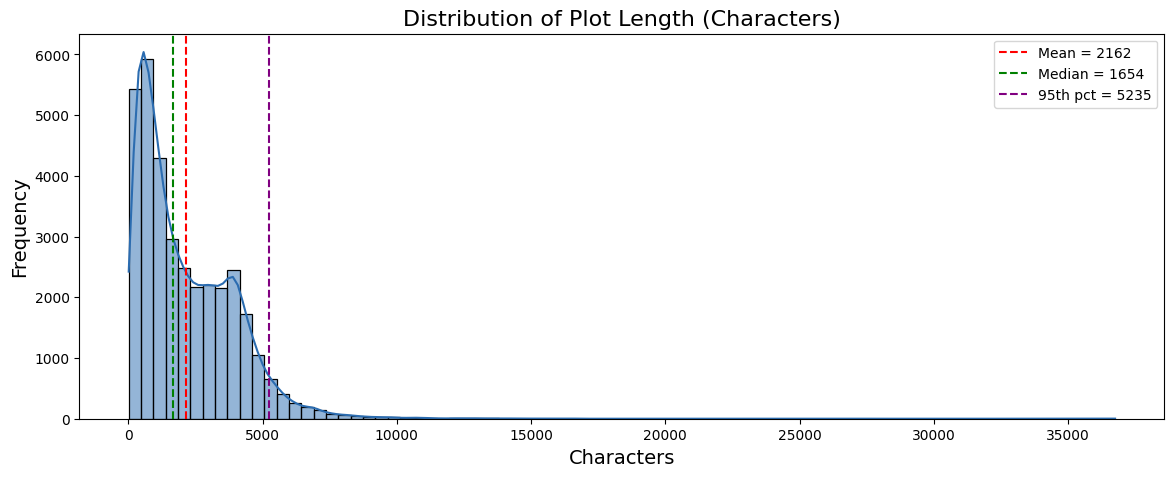

In [52]:
hist(
    df["n_chars"],
    "Distribution of Plot Length (Characters)",
    "Characters",
    bins=80
)

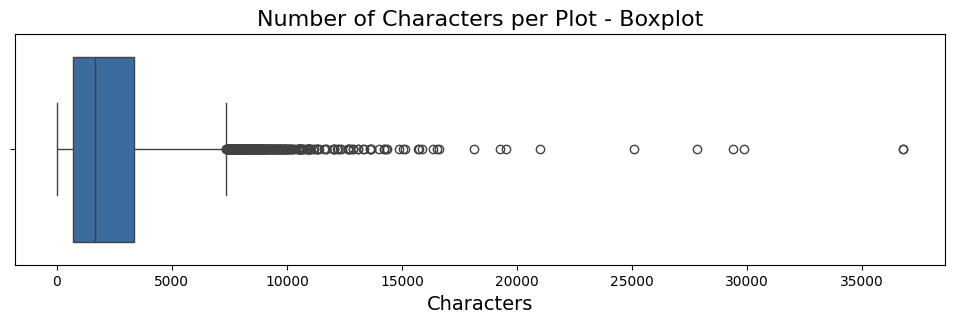

In [53]:
boxplot(
    df["n_chars"],
    "Number of Characters per Plot - Boxplot",
    "Characters"
)

Most plot summaries are relatively short, but the distribution exhibits a clear **long-tail pattern**, as shown in the histogram and boxplot above. While the majority of plots fall within a few thousand characters, a small fraction extends well beyond this range, with some narratives exceeding **30,000 characters**.

This heavy-tailed distribution has important implications for segmentation. Because document length varies widely across the dataset, selecting a single chunk size inevitably involves a trade-off.
* Smaller chunk sizes work well for short plots, allowing the system to capture fine-grained narrative segments. However, they can fragment longer plots into many small pieces, potentially breaking semantic continuity.
* Larger chunk sizes preserve the flow of longer narratives, but short plots may end up inside chunks that are unnecessarily large, reducing segmentation granularity.

Rather than attempting to eliminate this trade-off, the goal is to anchor chunking decisions in the empirical properties of the dataset. By understanding how plot lengths are distributed, we can select parameters that provide a reasonable balance across both typical and extreme cases.

This perspective motivates the **length-driven chunking strategy** introduced in the following sections.

## **Paragraph Structure**

Paragraph boundaries may initially appear to be natural segmentation points for text chunking. In practice, however, most Wikipedia movie plots are written as a single continuous block of text, with very few paragraph breaks. This limits the usefulness of paragraph boundaries as reliable splitting points.

To quantify this property, we count the number of paragraphs in each plot by splitting the normalized text on double newline characters.

In [54]:
def count_paragraphs(text):
    return len([p for p in text.split("\n\n") if p.strip()])

df["n_paragraphs"] = df["plot_norm"].apply(count_paragraphs)

df["n_paragraphs"].describe(percentiles=[0.5,0.75,0.9,0.95])

count    34886.000000
mean         1.001032
std          0.067291
min          1.000000
50%          1.000000
75%          1.000000
90%          1.000000
95%          1.000000
max         11.000000
Name: n_paragraphs, dtype: float64

The resulting statistics reveal an extremely limited variation in paragraph counts across the dataset.
- The **median number of paragraphs is 1**
- Even the **95th percentile remains at 1**
- Only a small minority of entries contain multiple paragraphs

This means that the vast majority of plot summaries are written as single-paragraph narratives. As a result, paragraph boundaries provide very little structural information for guiding text segmentation. In most cases, relying on paragraph-based splitting would simply return the entire plot as a single unit.

Consequently, paragraph structure cannot serve as a primary criterion for segmentation in chunking strategies for this dataset.

## **Line Structure**

Line breaks sometimes separate narrative units, but their usage is highly inconsistent across entries. Some plots contain several short lines, while others appear as a single continuous line of text.

To examine how frequently line breaks occur in the dataset, we count the number of non-empty lines in each plot.

In [55]:
def count_lines(text):
    return len([l for l in text.split("\n") if l.strip()])

df["n_lines"] = df["plot_norm"].apply(count_lines)

df["n_lines"].describe(percentiles=[0.5,0.75,0.9,0.95])

count    34886.000000
mean         3.773835
std          3.004070
min          1.000000
50%          3.000000
75%          6.000000
90%          8.000000
95%          9.000000
max         53.000000
Name: n_lines, dtype: float64

The resulting statistics reveal moderate variation in line counts:
- **Median**: 3 lines per plot
- **Mean**: ~3.8 lines
- **95th percentile**: 9 lines

These values indicate that most plots contain only a few line breaks, with half of the entries having three lines or fewer. However, the standard deviation of roughly three lines and the presence of much larger values (up to 53 lines) indicate that line usage varies substantially across the dataset.

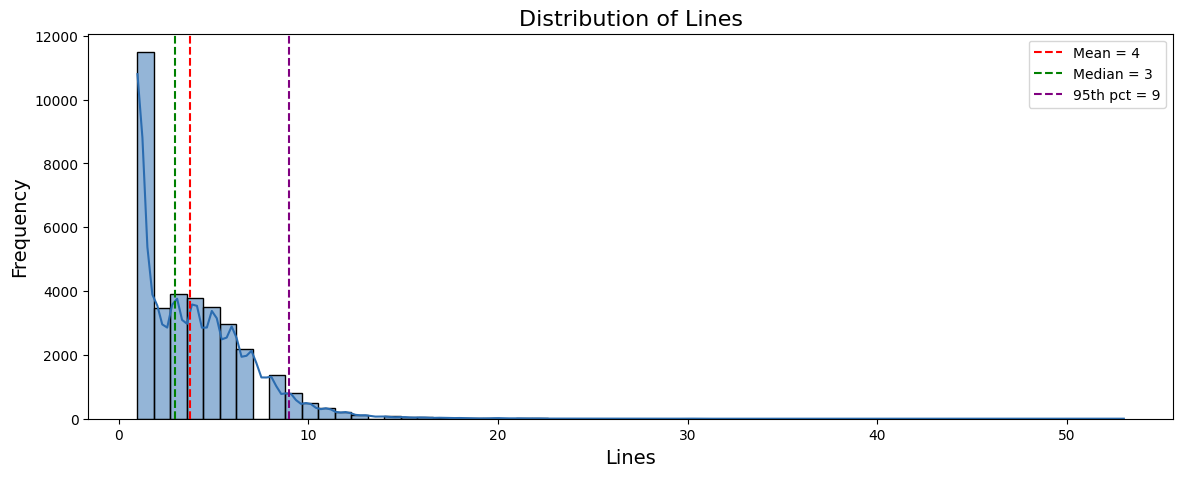

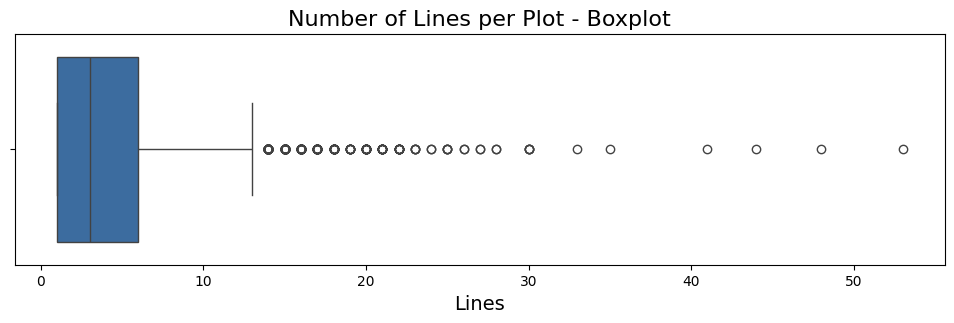

In [56]:
hist(
    df["n_lines"],
    "Distribution of Lines",
    "Lines",
    bins=60
)

boxplot(
    df["n_lines"],
    "Number of Lines per Plot - Boxplot",
    "Lines"
)

The histogram and boxplot above show that while most plots contain only a few lines, a minority includes a much larger number of line breaks. However, the number of lines alone does not determine whether newline-based splitting is useful. The length of each line also plays a critical role. To better understand this aspect, we compute the maximum line length for each plot.

In [57]:
def max_line_length(text):
    lines = [l for l in text.split("\n") if l.strip()]
    if not lines:
        return 0
    return max(len(l) for l in lines)

df["max_line_chars"] = df["plot_norm"].apply(max_line_length)

df["max_line_chars"].describe(percentiles=[0.5,0.75,0.9,0.95])

count    34886.000000
mean       784.259158
std        474.038333
min         15.000000
50%        721.000000
75%        996.000000
90%       1304.500000
95%       1552.000000
max      16599.000000
Name: max_line_chars, dtype: float64

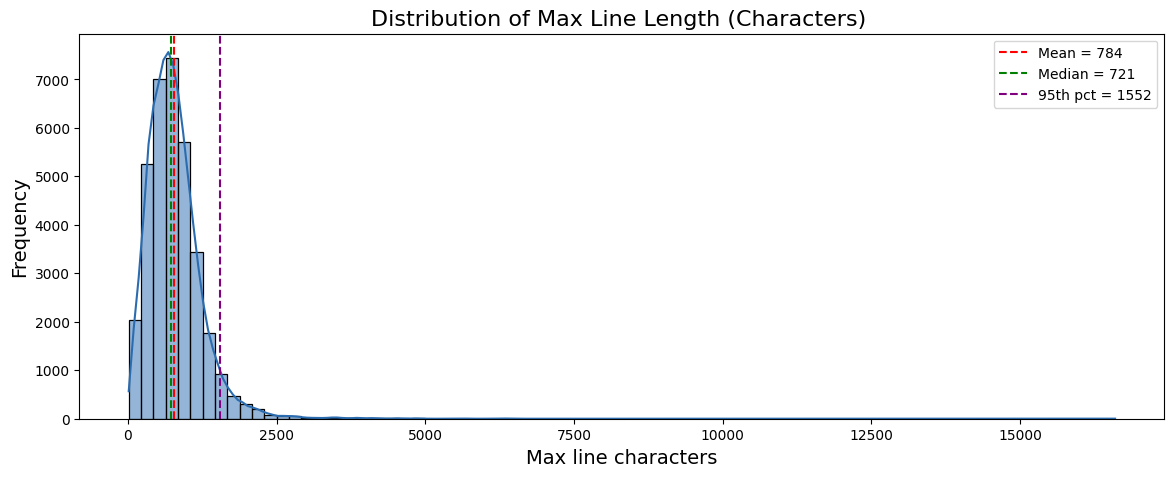

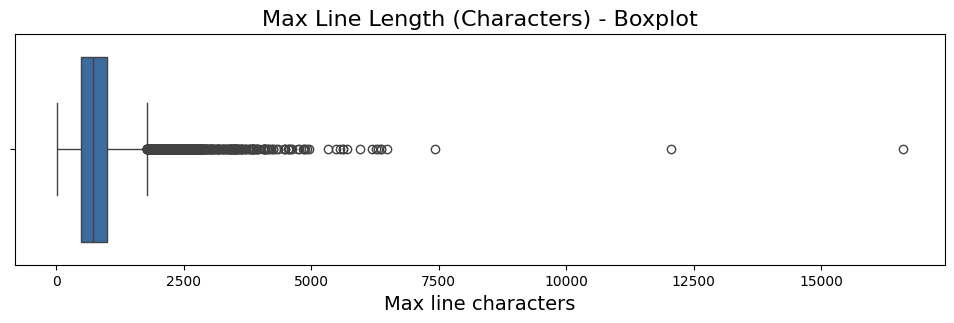

In [58]:
hist(
    df["max_line_chars"],
    "Distribution of Max Line Length (Characters) ",
    "Max line characters",
    bins=80
)

boxplot(
    df["max_line_chars"],
    "Max Line Length (Characters) - Boxplot",
    "Max line characters"
)

The statistics for maximum line length reveal an important pattern:
- **Median maximum line length**: ~721 characters
- **Mean**: ~784 characters
- **95th percentile**: ~1552 characters

This means that many plots contain lines spanning several hundred characters, and some exceed **1,500 characters**.

Such long lines have important implications for segmentation. When newline-based splitting is used, each line becomes a separator-delimited unit that the splitter attempts to preserve.

Because of this behavior, overlap reuse can only occur when an entire line fits within the configured overlap window. If lines are longer than the overlap size, the splitter cannot reuse part of the previous segment.

As a result, newline-based chunking often produces adjacent chunks without effective overlap, even when a non-zero overlap parameter is configured.


## **From Structural Evidence to Chunking Strategy**

The structural analyses presented in the previous sections reveal an important limitation: formatting-based features such as paragraphs and line breaks are not reliable guides for segmentation in this dataset.

Paragraph boundaries are extremely rare, and newline usage varies widely across entries. As a result, segmentation strategies that rely primarily on formatting structure may behave inconsistently across plots.

By contrast, total character length spans a wide range of values across the dataset. Unlike newline-based metrics, which depend on formatting choices, character length reflects the actual length of each narrative and remains comparable across entries.

Because chunking ultimately operates under character or token limits, document length becomes a natural reference when reasoning about segmentation. It helps estimate how many chunks a document may produce and whether a chosen chunk size will unnecessarily fragment short plots or leave longer plots insufficiently segmented.

Taken together, these observations motivate a **length-driven chunking strategy**. In this approach, segmentation is governed primarily by chunk size constraints, while structural separators are used to preserve natural text boundaries whenever possible.

Rather than assuming that reliable paragraph or line boundaries exist across the dataset, the segmentation process begins with a maximum chunk size and attempts to split text at the largest available separators. If those separators cannot satisfy the size constraint, progressively smaller units, such as line breaks, spaces, or individual characters, are used until the limit is respected.

This approach reflects the structural properties observed in the dataset: paragraph boundaries are rare, line breaks are inconsistent, and narrative length varies substantially across plots. As a result, segmentation must remain robust to formatting variability while still preserving natural textual boundaries whenever possible.

The next section translates this design principle into a concrete baseline configuration for text splitting.

## **Defining a Baseline Chunking Configuration**

The structural observations discussed in the previous section suggest that segmentation should be governed primarily by chunk size rather than by unreliable structural boundaries.

To operationalize this **length-driven chunking strategy**, we adopt LangChain's `RecursiveCharacterTextSplitter`. This splitter implements a hierarchical segmentation procedure: it attempts to split the text using larger structural separators first and progressively falls back to smaller units when necessary to ensure that the maximum chunk size is respected.

In practice, the algorithm attempts to preserve natural boundaries such as paragraphs or line breaks whenever possible. When such boundaries are absent or inconsistent, the splitter progressively falls back to smaller units such as spaces or individual characters to satisfy the size constraint.

This behavior aligns with the structural variability observed in the dataset, where formatting features such as paragraphs and line breaks are unreliable indicators of semantic boundaries. Under these conditions, a hierarchical splitter that respects size constraints while preserving structural boundaries whenever possible provides a robust baseline.

The configuration below defines the baseline chunking parameters used in the experiments that follow. The list of separators corresponds to the **default separator hierarchy used by LangChain's** `RecursiveCharacterTextSplitter`, which attempts to split text in the following order: paragraph breaks, line breaks, spaces, and finally individual characters.

```python
RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)
```

### **Choosing Chunk Size and Overlap**

The baseline parameters are also informed by the empirical distribution of plot lengths observed in the dataset. The **distribution of plot length** shows a **median** of approximately **1.6k characters**, a **mean** around **2.1k**, and a long tail extending beyond **5k characters** at the **95th percentile**. This indicates that most plots are relatively short, while a smaller subset contains substantially longer narratives.

#### **Why `chunk_size = 1200`**

A chunk size of **1200 characters** provides a practical balance between fragmentation and coverage. Because the median plot length is around 1650 characters, many plots can be represented in **one or two chunks**, limiting unnecessary fragmentation of short narratives. At the same time, longer plots are divided into multiple segments, ensuring that large narratives remain manageable during retrieval.

Importantly, this value is chosen relative to the observed distribution of document lengths rather than relying on arbitrary parameter selection.

#### **Why `chunk_overlap = 200`**

A **200-character overlap** is introduced to preserve local narrative continuity between adjacent chunks. In narrative text, entities, references, and transitions often extend across multiple sentences. A small amount of overlap therefore helps maintain contextual coherence when chunks are later retrieved independently.

However, overlap should be interpreted as a **maximum overlap window rather than a guaranteed property of the segmentation process**. The recursive splitter first attempts to divide the text using structural separators such as paragraph breaks, line breaks, or spaces.

When such separators provide valid split points that keep the chunk within the configured size limit, the text can be divided at those boundaries. In these cases, the next chunk may begin directly at the detected boundary without reusing part of the previous segment.

Overlap occurs only when part of the preceding segment can be reused while still respecting the configured overlap window. If the separator-delimited unit (for example, a line) is larger than that window, it cannot be reused and the next chunk begins without overlap.

#### **Robustness to Formatting Variability**

These parameters are designed to remain robust under the formatting inconsistencies observed in the dataset:
- Paragraph boundaries are rare
- Line breaks are inconsistently used
- Some lines are extremely long

Under these conditions, chunking must be guided primarily by size constraints, while structural separators are used opportunistically to preserve natural text boundaries.

This design choice also avoids the pitfalls discussed in the companion analysis *"[When separator="\n" silently breaks chunk overlap in RAG pipelines](https://www.kaggle.com/code/ivanfrana/when-separator-n-silently-breaks-chunk-overlap)"*, where aggressive reliance on newline boundaries can unintentionally disable effective overlap behavior.

Together, these parameters define a practical baseline that:
- Limits unnecessary fragmentation of short plots
- Maintains manageable segment sizes for longer narratives
- Remains resilient to inconsistent formatting across the corpus

## **Inspecting Chunking Behavior**

Rather than assuming that a chunking configuration behaves as expected, it is useful to inspect how it segments real narratives.

The following cells illustrate how the baseline configuration divides movie plots into chunks of varying length. We begin by examining a few individual examples before performing a dataset-wide analysis of the resulting chunks.

In [59]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

In [60]:
sample_plots = df["plot_norm"].sample(3, random_state=42)

for i, plot in enumerate(sample_plots):

    chunks = splitter.split_text(plot)

    print("="*80)
    print(f"Example {i+1}")
    print("Original length:", len(plot))
    print("Number of chunks:", len(chunks))

    for j, chunk in enumerate(chunks):
        print(f"\nChunk {j+1} | length: {len(chunk)}")
        print(chunk)

Example 1
Original length: 4162
Number of chunks: 4

Chunk 1 | length: 1119
When a flying saucer lands in Washington, D.C., the Army quickly surrounds it. A humanoid (Michael Rennie) emerges, announcing that he has come in peace. When he unexpectedly opens a small device, he is shot by a nervous soldier. A tall robot emerges from the saucer and quickly disintegrates the soldiers' weapons. The alien orders the robot, Gort, to stop. He explains that the now-broken device was a gift for the President which would have enabled him "to study life on the other planets".
The alien, Klaatu, is taken to Walter Reed Hospital. After surgery, he uses a salve to quickly heal his wound. Meanwhile, the Army is unable to enter the saucer; Gort stands outside, silent and unmoving.
Klaatu tells the President's secretary, Mr. Harley (Frank Conroy), that he has a message that must be delivered to all the world's leaders simultaneously. Harley tells him that such a meeting in the current political climate i

The examples above illustrate how the recursive splitter segments narratives of different lengths. In these cases, the chunks are created without visible overlap between adjacent segments.

This behavior occurs because the recursive splitter prioritizes structural separators such as paragraph breaks, line breaks, and spaces before applying a size-based splitting procedure. When one of these separators provides a valid split point that keeps the chunk below the configured size limit, the text can be divided cleanly at that boundary without reusing content from the previous segment.

Overlap is introduced only when part of the preceding segment can be reused while still respecting the configured overlap window. If the separator-delimited unit (for example, a line) exceeds that window, the splitter cannot reuse it and the next chunk begins without overlap.

### **Dataset-wide Chunking Statistics**

To better understand how the recursive splitter behaves across the entire dataset, we compute several statistics describing the chunking process.

The following metrics summarize the results:
- **Total chunks**: the total number of text segments generated after splitting all plots in the dataset.
- **Chunk transitions**: the number of boundaries between consecutive chunks. For each document with *n* chunks, there are *(n − 1)* such transitions.
- **Overlaps detected**: the number of chunk transitions where textual overlap was actually applied.
- **Plots with overlap**: the number of documents that produced at least one overlapping chunk pair.
- **Overlap ratio**: the proportion of chunk transitions that exhibit overlap.

These statistics provide a dataset-level view of how frequently the overlap mechanism is activated during recursive splitting.

In [61]:
def compute_overlap(a: str, b: str, max_overlap: int = 200) -> int:
    max_len = min(len(a), len(b), max_overlap)

    for k in range(max_len, 0, -1):
        if a[-k:] == b[:k]:
            return k

    return 0

def analyze_chunking(df, splitter, max_overlap=200):

    all_chunks = []
    overlap_sizes = []
    chunk_pairs = 0
    plots_with_overlap = []

    for idx, plot in df["plot_norm"].items():

        chunks = splitter.split_text(plot)
        all_chunks.extend(chunks)

        plot_has_overlap = False

        for i in range(len(chunks) - 1):

            chunk_pairs += 1

            overlap = compute_overlap(
                chunks[i],
                chunks[i + 1],
                max_overlap=max_overlap
            )

            overlap_sizes.append(overlap)

            if overlap > 0:
                plot_has_overlap = True

        if plot_has_overlap:
            plots_with_overlap.append(idx)

    overlap_count = sum(1 for o in overlap_sizes if o > 0)

    return {
        "all_chunks": all_chunks,
        "overlap_sizes": overlap_sizes,
        "overlap_count": overlap_count,
        "chunk_pairs": chunk_pairs,
        "plots_with_overlap": plots_with_overlap
    }

In [62]:
result = analyze_chunking(df, splitter)

all_chunks = result["all_chunks"]
overlap_count = result["overlap_count"]
chunk_pairs = result["chunk_pairs"]
plots_with_overlap = result["plots_with_overlap"]

chunk_lengths = [len(c) for c in all_chunks]

The dataset-wide analysis provides a clearer picture of how overlap is applied in practice. Although the splitter was configured with a **200-character overlap**, overlap appears only in a subset of chunk transitions rather than being applied uniformly.

Across the entire corpus, the chunking process produced **95,942 chunks** and **61,056 chunk transitions**, of which **7,598 transitions contained overlap**, corresponding to an overlap ratio of approximately **12.4%**. Similarly, **5,539 plots** generated at least one overlapping chunk pair.

These statistics confirm the behavior observed in the examples: overlap tends to appear only when the splitter cannot rely on structural separators to produce chunks that satisfy the configured size constraint. In such situations, the algorithm falls back to a size-driven splitting procedure, where part of the preceding segment may be reused while still respecting the configured overlap window. When suitable separators are available, the text can instead be divided cleanly at those boundaries without reusing content from the previous segment.

These results highlight an important property of **recursive chunking**: the overlap parameter defines a maximum overlap window, but its actual application depends on how the text structure interacts with both the chunk size constraint and the separator hierarchy.

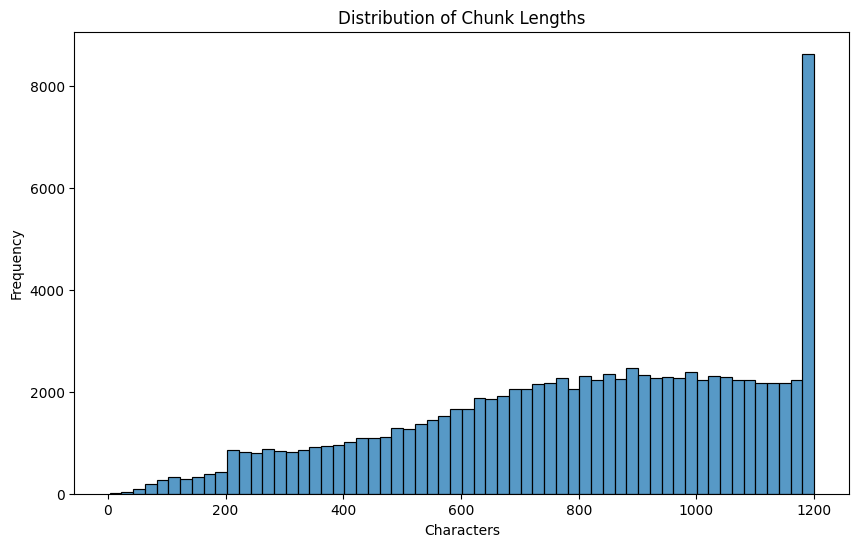

In [63]:
plt.figure(figsize=(10,6))

sns.histplot(chunk_lengths, bins=60)

plt.title("Distribution of Chunk Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

The distribution of chunk lengths provides additional insight into the behavior of the splitter. Most chunks cluster near the configured maximum size of **1200 characters**, indicating that the splitter tends to accumulate text until the size constraint is reached.

Smaller chunks typically appear near the end of documents or when structural separators trigger an earlier split. In these situations, the algorithm preserves the detected boundary instead of extending the chunk to reach the maximum configured size.

This pattern indicates that the chunking process balances two objectives: respecting natural textual boundaries while keeping chunks close to the configured size limit whenever possible.

In [64]:
for example_idx in plots_with_overlap[:3]:

    plot = df.loc[example_idx, "plot_norm"]
    chunks = splitter.split_text(plot)

    print("="*80)
    print(f"Plot index: {example_idx}")
    print("Original length:", len(plot))
    print("Number of chunks:", len(chunks))

    for j, chunk in enumerate(chunks):
        print(f"\nChunk {j+1} | length: {len(chunk)}")
        print(chunk)

Plot index: 8
Original length: 3623
Number of chunks: 4

Chunk 1 | length: 886
The opening scene shows the interior of the robbers' den. The walls are decorated with the portraits of notorious criminals and pictures illustrating the exploits of famous bandits. Some of the gang are lounging about, while others are reading novels and illustrated papers. Although of youthful appearance, each is dressed like a typical Western desperado. The "Bandit Queen," leading a blindfolded new recruit, now enters the room. He is led to the center of the room, raises his right hand and is solemnly sworn in. When the bandage is removed from his eyes he finds himself looking into the muzzles of a dozen or more 45's. The gang then congratulates the new member and heartily shake his hand. The "Bandit Queen" who is evidently the leader of the gang, now calls for volunteers to hold up a train. All respond, but she picks out seven for the job who immediately leave the cabin.

Chunk 2 | length: 1114
The next s

The examples above illustrate situations where overlap is effectively applied. These cases typically occur when a narrative segment extends beyond the configured chunk size and the recursive splitter cannot rely solely on structural separators to keep all chunks within the size constraint.

In such situations, the splitter falls back to a size-driven splitting procedure. When this happens, part of the preceding segment may still fit within the configured overlap window and can therefore be reused in the next chunk, producing overlapping segments that preserve contextual continuity between consecutive chunks.

## **Conclusion**

This analysis provides a practical view of how recursive chunking behaves when applied to real narrative text.

The inspection of individual plots showed that chunks are often formed without visible overlap. This may initially appear surprising, since the splitter was configured with a **200-character overlap**. However, the dataset-wide analysis clarifies how often overlap is actually applied.

Across the full corpus, the splitter generated nearly **96,000 chunks** and more than **61,000 chunk transitions**, of which **7,598 transitions contained overlap**, corresponding to an overlap ratio of approximately **12.4%**. In addition, **5,539 plots** produced at least one overlapping chunk pair.

This pattern follows directly from the design of the `RecursiveCharacterTextSplitter`. Rather than applying a fixed sliding window, the algorithm first attempts to segment the text using a hierarchy of structural separators (paragraph breaks, line breaks, spaces). When these separators provide valid split points that keep chunks within the configured size constraint, the text can be divided without reusing part of the previous segment.

This behavior also helps explain an important issue discussed in the companion analysis *"[When separator="\n" silently breaks chunk overlap in RAG pipelines](https://www.kaggle.com/code/ivanfrana/when-separator-n-silently-breaks-chunk-overlap)"*. In that experiment, the interaction between line-based boundaries and chunk capacity prevented overlap from propagating even when it was explicitly configured.

Although the mechanism differs slightly here, a related structural effect appears. When newline characters are treated as primary splitting boundaries, the recursive splitter often finds valid split points before the configured chunk size limit is reached. In these situations, the text can be divided cleanly at those boundaries without reusing content from the previous segment, producing chunks without overlap even though overlap was configured.

This means that separator configuration can significantly influence how often overlap is actually applied. In corpora where newline characters are frequent or inconsistently used, the overlap mechanism may activate less frequently than expected, producing chunks that share little or no overlapping text.

Together, the qualitative inspection and the dataset-wide statistics highlight a key practical insight:

> In recursive chunking strategies, **text structure often dominates parameter configuration**.

Understanding how chunk size, overlap, and separator hierarchies interact is therefore essential when designing chunking strategies for Retrieval-Augmented Generation pipelines. Rather than relying solely on parameter choices, effective segmentation requires examining how the splitter behaves on the actual corpus being indexed. In retrieval pipelines, this behavior can influence how context is distributed across chunks, potentially affecting recall and answer grounding.